In [ ]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

def find_project_root(start=None):
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'requirements.txt').exists() and (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError('Project root not found')

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.data_loading import load_csv_files, build_image_path
from src.preprocessing import split_train_validation, get_train_transforms, get_eval_transforms, ImageClassificationDataset
from src.baseline_cnn import BaselineCNN
from src.training import get_device, fit

print('Imports successful')

Imports successful


In [ ]:
train_df, _ = load_csv_files()
train_split_df, val_split_df = split_train_validation(train_df, val_size=0.2, seed=42)

train_transform = get_train_transforms(32)
val_transform = get_eval_transforms(32)

train_paths = [build_image_path(row.Id, split='train', label=row.Category) for row in train_split_df.itertuples(index=False)]
val_paths   = [build_image_path(row.Id, split='train', label=row.Category) for row in val_split_df.itertuples(index=False)]

train_dataset = ImageClassificationDataset(train_paths, train_split_df['Category'].tolist(), transform=train_transform)
val_dataset   = ImageClassificationDataset(val_paths,   val_split_df['Category'].tolist(),   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=0)

print(f'Train samples: {len(train_dataset)}  |  Val samples: {len(val_dataset)}')

Train samples: 13600  |  Val samples: 3400


In [ ]:
device = get_device()
print(f'Device: {device}')

model = BaselineCNN(num_classes=10).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

Device: mps
Trainable parameters: 1,272,618


In [ ]:
# Hyperparameters and output paths
OUTPUT_DIR = ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

print('Criterion: CrossEntropyLoss with label_smoothing=0.1')
print('Optimizer: AdamW  lr=1e-3  weight_decay=1e-4')

Criterion: CrossEntropyLoss with label_smoothing=0.1
Optimizer: AdamW  lr=1e-3  weight_decay=1e-4


In [ ]:
# Train
history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=30,
    patience=7,
    save_path=OUTPUT_DIR / 'baseline_cnn.pt',
)

Epoch 01/30  lr=1.00e-03  train loss=0.9972 acc=0.8245  val loss=0.5635 acc=0.9954
  ✓ New best — saved to /Users/Valeria/Desktop/Image_Video_Processing_Project_Group_17/outputs/baseline_cnn.pt
Epoch 02/30  lr=9.76e-04  train loss=0.6434 acc=0.9822  val loss=0.5288 acc=0.9968
  ✓ New best — saved to /Users/Valeria/Desktop/Image_Video_Processing_Project_Group_17/outputs/baseline_cnn.pt
Epoch 03/30  lr=9.05e-04  train loss=0.6011 acc=0.9924  val loss=0.5250 acc=0.9959
  ✓ New best — saved to /Users/Valeria/Desktop/Image_Video_Processing_Project_Group_17/outputs/baseline_cnn.pt
Epoch 04/30  lr=7.94e-04  train loss=0.5796 acc=0.9954  val loss=0.5133 acc=0.9977
  ✓ New best — saved to /Users/Valeria/Desktop/Image_Video_Processing_Project_Group_17/outputs/baseline_cnn.pt
Epoch 05/30  lr=6.55e-04  train loss=0.5686 acc=0.9963  val loss=0.5147 acc=0.9977
Epoch 06/30  lr=5.01e-04  train loss=0.5581 acc=0.9985  val loss=0.5125 acc=0.9977
  ✓ New best — saved to /Users/Valeria/Desktop/Image_Video

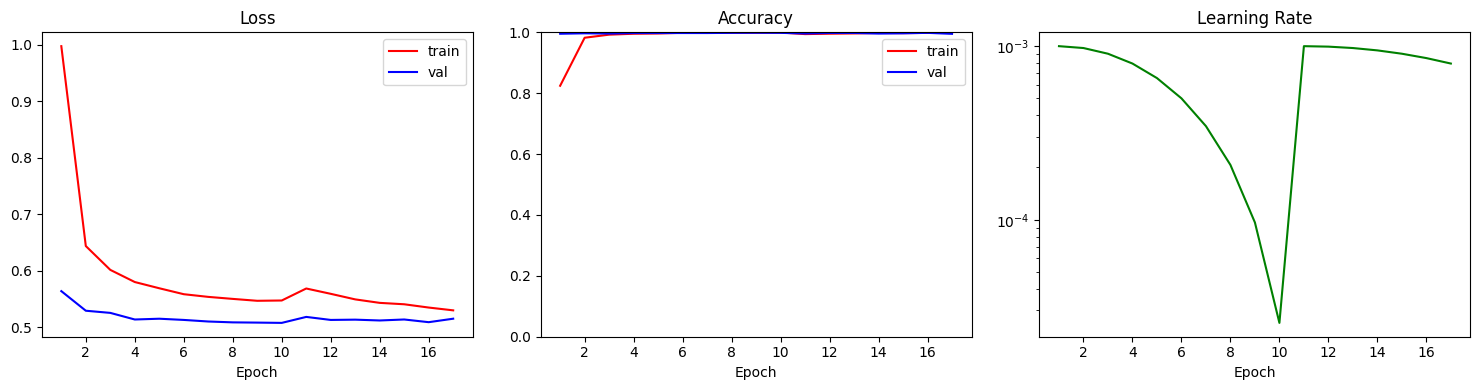

Plot saved.


In [ ]:
epochs_run = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_run, history['train_loss'], label='train', color='red')
axes[0].plot(epochs_run, history['val_loss'],   label='val',   color='blue')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].plot(epochs_run, history['train_accuracy'], label='train', color='red')
axes[1].plot(epochs_run, history['val_accuracy'],   label='val',   color='blue')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[2].plot(epochs_run, history['lr'], color='green')
axes[2].set_title('Learning Rate')
axes[2].set_xlabel('Epoch')
axes[2].set_yscale('log')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

In [ ]:
# summary
best_val_acc = max(history['val_accuracy'])
best_epoch   = history['val_accuracy'].index(best_val_acc) + 1

print(f'Best val accuracy: {best_val_acc:.4f}  (epoch {best_epoch})')
print(f'Final train acc: {history["train_accuracy"][-1]:.4f}')
print(f'Final val acc: {history["val_accuracy"][-1]:.4f}')
print(f'Checkpoint saved: {OUTPUT_DIR / "baseline_cnn.pt"}')


Best val accuracy : 0.9986  (epoch 9)
Final train acc   : 0.9993
Final val acc     : 0.9951
Checkpoint saved  : /Users/Valeria/Desktop/Image_Video_Processing_Project_Group_17/outputs/baseline_cnn.pt
